In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
from scipy.stats import linregress
import datetime

In [3]:
columns = ['timestamp', 'presion', 'temperatura', 'flujo']
df = pd.read_csv('lowEd_band_lim_Marzo2012.dat', sep=' ',index_col=False, header=None, names=columns)
#df = pd.read_csv('muon_banda_lim_Marzo2012.dat', sep=' ',index_col=False, header=None, names=columns)
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

In [4]:
df

,timestamp,presion,temperatura,flujo
0,2012-03-01 13:44:00,918.09,23.4,9438.0
1,2012-03-01 13:45:00,917.93,23.5,9382.0
2,2012-03-01 13:48:00,917.98,23.4,9444.0
3,2012-03-01 13:49:00,917.95,23.4,9447.0
4,2012-03-01 13:50:00,917.86,23.2,9493.0
...,...,...,...,...
43429,2012-04-02 23:36:00,917.80,26.0,9582.0
43430,2012-04-02 23:37:00,917.81,26.0,9569.0
43431,2012-04-02 23:38:00,917.78,26.0,9450.0
43432,2012-04-02 23:39:00,917.74,26.1,9629.0


In [4]:
df_binned = df.resample('1H', on='timestamp').mean().dropna().reset_index() #bineado de 1h

In [5]:
df_binned

,timestamp,presion,temperatura,flujo
0,2012-03-01 13:00:00,917.984667,23.413333,9431.000000
1,2012-03-01 14:00:00,917.704237,23.894915,9136.762712
2,2012-03-01 15:00:00,918.260847,24.193220,9214.220339
3,2012-03-01 16:00:00,918.463390,24.211864,9189.983051
4,2012-03-01 17:00:00,918.212712,23.852542,9531.220339
...,...,...,...,...
736,2012-04-02 19:00:00,918.746271,27.161017,8974.169492
737,2012-04-02 20:00:00,918.112881,27.052542,8766.525424
738,2012-04-02 21:00:00,917.848475,26.720339,8948.135593
739,2012-04-02 22:00:00,917.575085,26.289831,8841.118644


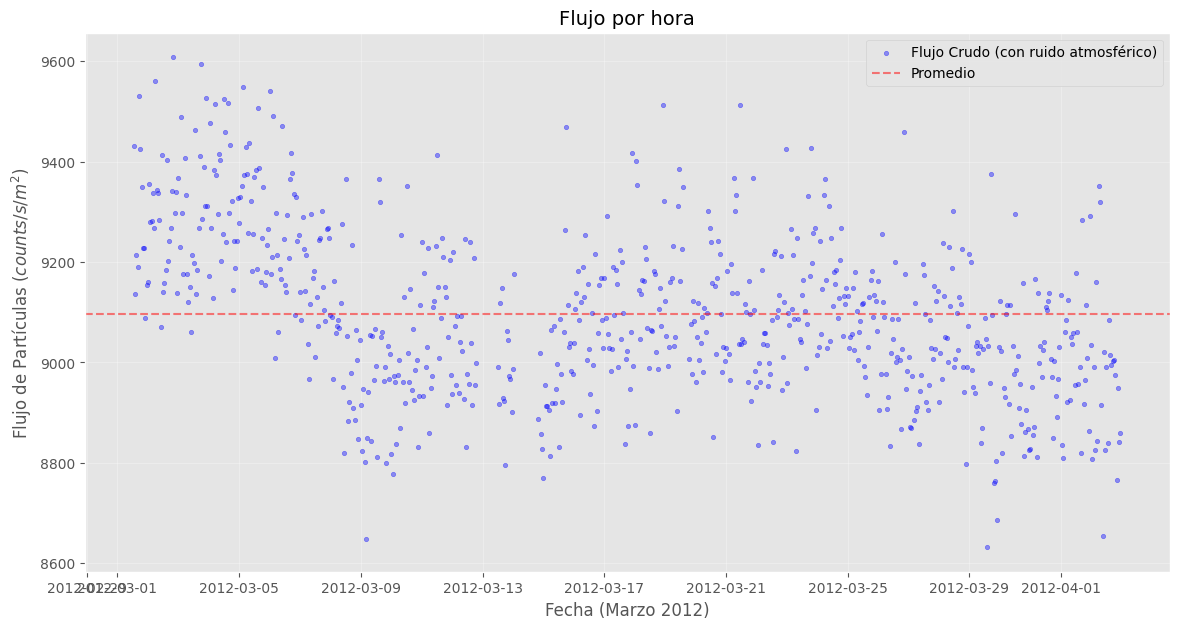

In [6]:
# Visualización básica
plt.figure(figsize=(14, 7))

# Flujos
plt.scatter(df_binned['timestamp'], df_binned['flujo'], 
            color='blue', s=10, alpha=0.4, label='Flujo Crudo (con ruido atmosférico)')

# Línea de referencia (para ver la estabilidad)
plt.axhline(df_binned['flujo'].mean(), color='red', linestyle='--', alpha=0.5, label='Promedio')

plt.title('Flujo por hora', fontsize=14)
plt.xlabel('Fecha (Marzo 2012)', fontsize=12)
plt.ylabel('Flujo de Partículas ($counts/s/m^2$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.xlim(datetime.datetime(2012, 3, 7), datetime.datetime(2012, 3, 12))
plt.show()

Text(0, 0.5, 'Presión promedio')

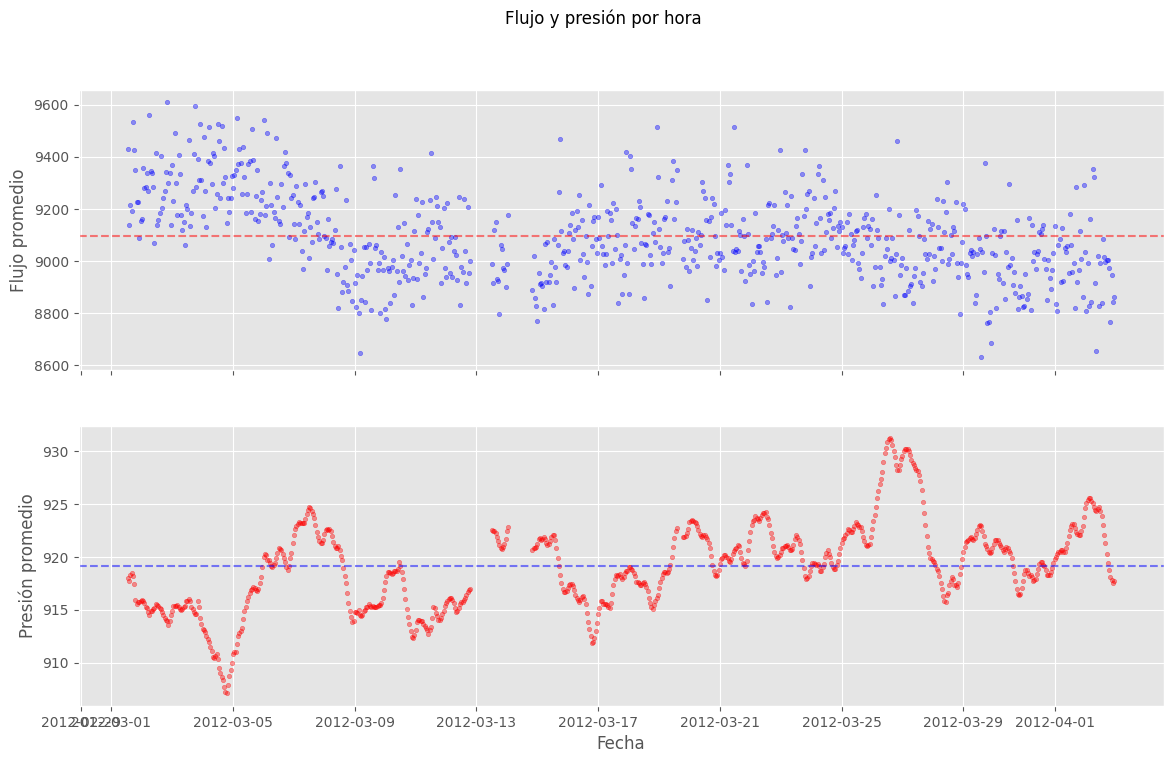

In [7]:
# Visualización de flujo y presión
fig, axs = plt.subplots(2, sharex=True,figsize=(14, 8))
fig.suptitle('Flujo y presión por hora')
plt.xlabel('Fecha')
#axs.set_aspect('equal')
axs[0].scatter(df_binned['timestamp'], df_binned['flujo'],color='blue', s=10, alpha=0.4, label='Flujo')
axs[0].axhline(df_binned['flujo'].mean(), color='red', linestyle='--', alpha=0.5, label='Promedio')
axs[0].set_ylabel('Flujo promedio')
#plt.legend()

axs[1].scatter(df_binned['timestamp'], df_binned['presion'],color='red', s=10, alpha=0.4, label='Presión atmosférica')
axs[1].axhline(df_binned['presion'].mean(), color='blue', linestyle='--', alpha=0.5, label='Promedio')
axs[1].set_ylabel('Presión promedio')

In [8]:
# Corrección por presión atmosférica
x = df_binned['presion']
y = np.log(df_binned['flujo'])
slope, intercept, r_value, p_value, std_err = linregress(x, y)
beta = -slope 
r_squared = r_value**2

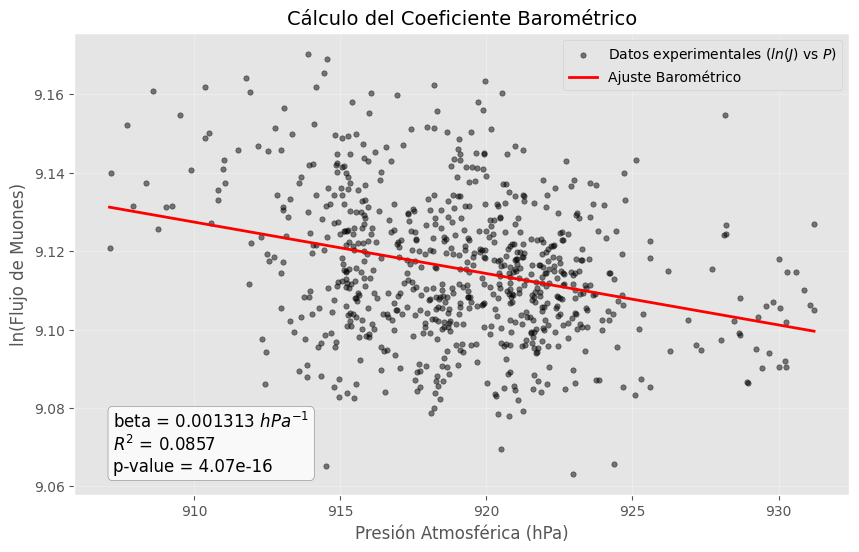

In [9]:
# 3. Recta de calibración
plt.figure(figsize=(10, 6))

# Datos experimentales
plt.scatter(x, y, color='black', s=15, alpha=0.5, label='Datos experimentales ($ln(J)$ vs $P$)')

# Recta de ajuste
x_range = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_range + intercept
plt.plot(x_range, y_fit, color='red', linewidth=2, label='Ajuste Barométrico')

# Anotación de resultados estadísticos
texto_stats = (f'beta = {beta:.6f} $hPa^{{-1}}$\n'
               f'$R^2$ = {r_squared:.4f}\n'
               f'p-value = {p_value:.2e}')

plt.annotate(texto_stats, xy=(0.05, 0.05), xycoords='axes fraction', 
             fontsize=12, bbox=dict(boxstyle="round", fc="white", ec="gray", alpha=0.8))

plt.xlabel('Presión Atmosférica (hPa)', fontsize=12)
plt.ylabel('ln(Flujo de Muones)', fontsize=12)
plt.title('Cálculo del Coeficiente Barométrico', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

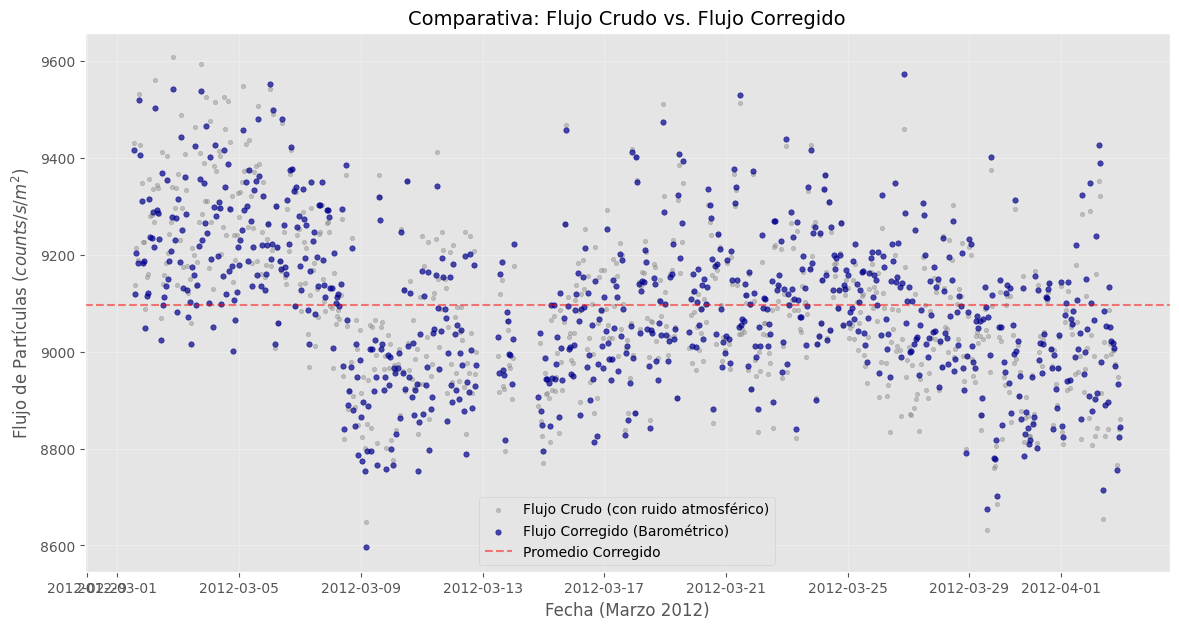

In [10]:
#Corrección del flujo con el ajuste barométrico

# Definimos la presión de referencia (P0) como la media del mes
P0 = df_binned['presion'].mean()

# Aplicamos la fórmula de corrección barométrica
df_binned['flujo_corr'] = df_binned['flujo'] * np.exp(beta * (df_binned['presion'] - P0))

# Ahora, el Bloque 6: Visualización comparativa
plt.figure(figsize=(14, 7))

# Graficamos ambos flujos (crudo vs corregido)
plt.scatter(df_binned['timestamp'], df_binned['flujo'], 
            color='gray', s=10, alpha=0.4, label='Flujo Crudo (con ruido atmosférico)')
plt.scatter(df_binned['timestamp'], df_binned['flujo_corr'], 
            color='darkblue', s=15, alpha=0.7, label='Flujo Corregido (Barométrico)')

# Línea de referencia (para ver la estabilidad)
plt.axhline(df_binned['flujo_corr'].mean(), color='red', linestyle='--', alpha=0.5, label='Promedio Corregido')

plt.title('Comparativa: Flujo Crudo vs. Flujo Corregido', fontsize=14)
plt.xlabel('Fecha (Marzo 2012)', fontsize=12)
plt.ylabel('Flujo de Partículas ($counts/s/m^2$)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
#plt.xlim(datetime.datetime(2012, 3, 7), datetime.datetime(2012, 3, 12))
plt.show()